# Plot Training Results

This notebook loads a selected run log from `log/` and plots `train`, `val`, and `hella` metrics.

In [5]:
from pathlib import Path
import re
import matplotlib.pyplot as plt

In [6]:
LOG_DIR = Path('log')
log_files = sorted(LOG_DIR.glob('*.log'))

print('Available run logs:')
for p in log_files:
    print('-', p.name)

# Set this to a specific file name in log/ (for example: 'my_run.log').
# Leave as None to auto-pick the latest .log file.
RUN_LOG_NAME = None

if not log_files:
    raise FileNotFoundError('No .log files found in log/.')

if RUN_LOG_NAME is None:
    run_log = max(log_files, key=lambda p: p.stat().st_mtime)
else:
    run_log = LOG_DIR / RUN_LOG_NAME
    if not run_log.exists():
        raise FileNotFoundError(f'Log file not found: {run_log}')

print(f'Using log file: {run_log}')

Available run logs:
- gpt2_fineweb_default__l12_h12_e768__tbs524288_mb32_seq1024_steps10.log
- gpt2_fineweb_default__l12_h12_e768__tbs524288_mb32_seq1024_steps19073.log
Using log file: log/gpt2_fineweb_default__l12_h12_e768__tbs524288_mb32_seq1024_steps19073.log


In [7]:
metric_re = re.compile(r'^(\d+)\s+(train|val|hella)\s+([-+]?\d*\.?\d+)$')
metrics = {'train': [], 'val': [], 'hella': []}
meta = {'run_name': [], 'device': [], 'grad_accum_steps': []}

with run_log.open('r', encoding='utf-8') as f:
    for raw_line in f:
        line = raw_line.strip()
        if not line:
            continue
        if line.startswith('run_name '):
            meta['run_name'].append(line.split(' ', 1)[1])
            continue
        if line.startswith('device '):
            meta['device'].append(line.split(' ', 1)[1])
            continue
        if line.startswith('grad_accum_steps '):
            meta['grad_accum_steps'].append(line.split(' ', 1)[1])
            continue
        m = metric_re.match(line)
        if m:
            step = int(m.group(1))
            metric = m.group(2)
            value = float(m.group(3))
            metrics[metric].append((step, value))

for k in metrics:
    metrics[k].sort(key=lambda x: x[0])

print('Parsed points:')
for k, vals in metrics.items():
    print(f'- {k}: {len(vals)}')

if meta['run_name']:
    print('Run name(s):', sorted(set(meta['run_name'])))
if meta['device']:
    print('Device(s):', sorted(set(meta['device'])))
if meta['grad_accum_steps']:
    print('Grad accum step(s):', sorted(set(meta['grad_accum_steps'])))

Parsed points:
- train: 14711
- val: 59
- hella: 59
Run name(s): ['gpt2_fineweb_default__l12_h12_e768__tbs524288_mb32_seq1024_steps19073']
Device(s): ['cuda:0', 'cuda:1', 'cuda:2', 'cuda:3']
Grad accum step(s): ['4']


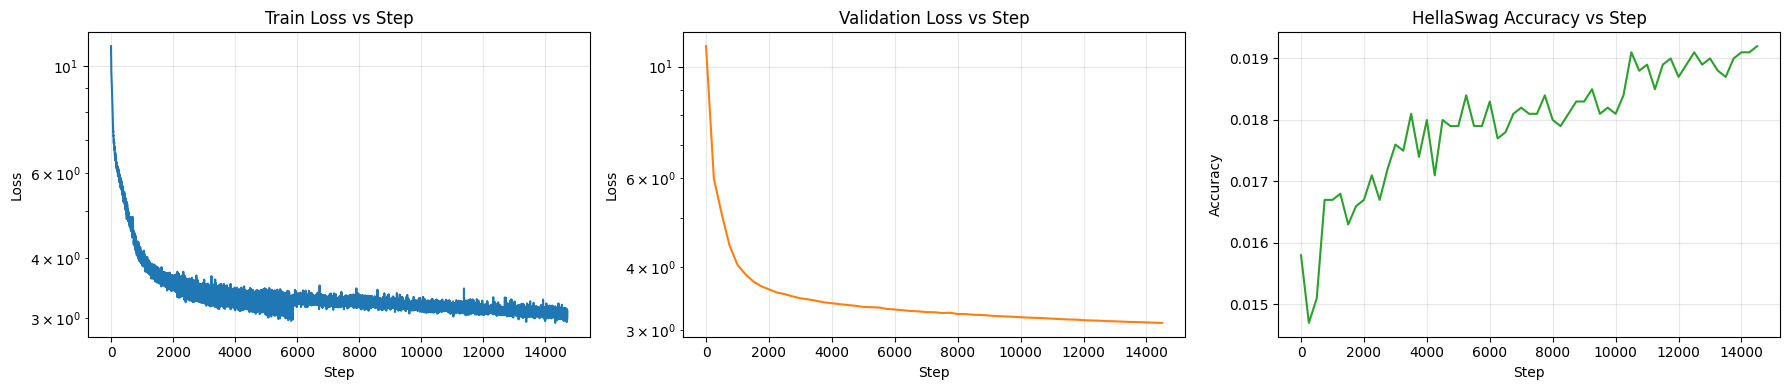

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Train loss
if metrics['train']:
    x, y = zip(*metrics['train'])
    # axes[0].plot(x, y, marker='o', color='tab:blue')
    axes[0].plot(x, y, color='tab:blue')
else:
    axes[0].text(0.5, 0.5, 'No train data', ha='center', va='center', transform=axes[0].transAxes)
axes[0].set_title('Train Loss vs Step')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Validation loss
if metrics['val']:
    x, y = zip(*metrics['val'])
    # axes[1].plot(x, y, marker='s', color='tab:orange')
    axes[1].plot(x, y, color='tab:orange')
else:
    axes[1].text(0.5, 0.5, 'No val data', ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_title('Validation Loss vs Step')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

# HellaSwag accuracy
if metrics['hella']:
    x, y = zip(*metrics['hella'])
    # axes[2].plot(x, y, marker='^', color='tab:green')
    axes[2].plot(x, y, color='tab:green')
else:
    axes[2].text(0.5, 0.5, 'No HellaSwag data', ha='center', va='center', transform=axes[2].transAxes)
axes[2].set_title('HellaSwag Accuracy vs Step')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Accuracy')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()